## CIRCUITO 1

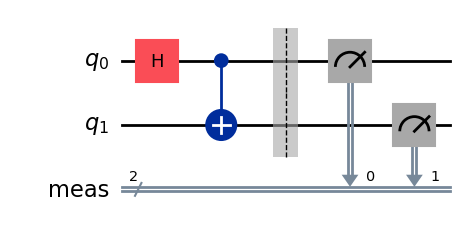

In [8]:
from qiskit import QuantumCircuit 
import matplotlib.pyplot as plt 
qc = QuantumCircuit(2) 
qc.h(0) 
qc.cx(0, 1) 
qc.measure_all() 
qc.draw("mpl") 


## CIRCUITO 2

In [9]:
# Hago las importaciones necesarias
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit import transpile
import matplotlib.pyplot as plt 

In [13]:
qc = QuantumCircuit(2) # Definimos un circuito de 2 qubits
qc.h(0) # Añadimos una puerta Hadamard al primer qubit
qc.cx(0, 1) # Añadimos una puerta CNOT entre el primer y el segundo qubit 0 es de control y 1 es de objetivo
qc.measure_all() # Medimos todos los qubits


In [14]:
# Inicializar el simulador
simulator = AerSimulator()

In [15]:
# Transpilar el circuito
# El transpile paso es necesario para optimizar el circuito para el backend específico
transpiled_qc = transpile(qc, simulator)

In [16]:
# Ejecutar el circuito
# Ejecutar el circuito en el simulador 1024 veces
result = simulator.run(transpiled_qc, shots=1024).result()

In [ ]:
# Obtener los resultados de las mediciones
counts = result.get_counts()
print("Resultados de la medición:", counts)

Resultados de la medición: {'00': 516, '11': 508}


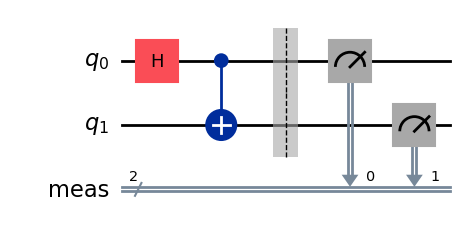

In [18]:
# Dibujar el circuito
qc.draw(output='mpl')

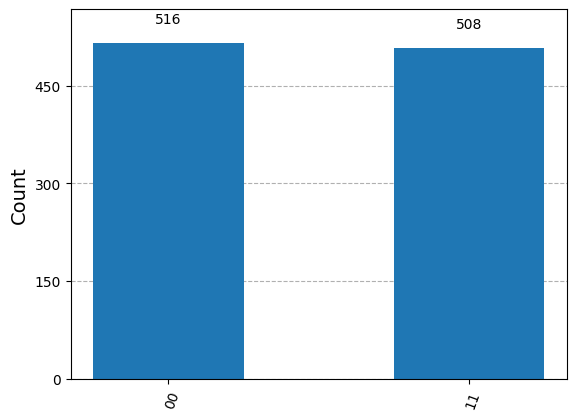

In [26]:
from qiskit.visualization import plot_histogram 
plot_histogram(counts) 

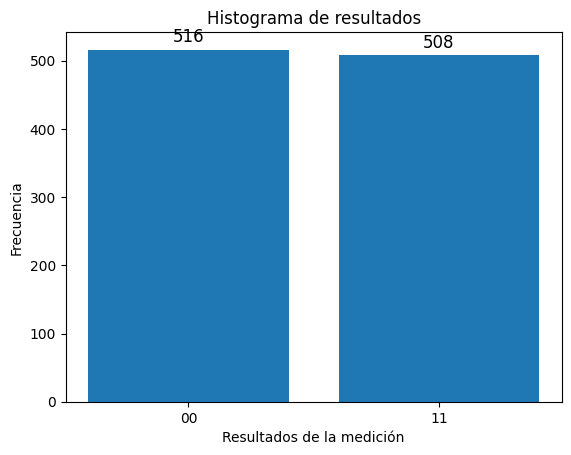

In [25]:
# Mostrar la gráfica de los resultados de la medición
plt.bar(counts.keys(), counts.values())
valores = list(counts.values())
for i, valor in enumerate(valores):
    plt.text(i, valor + max(valores)*0.01, str(valor), ha='center', va='bottom', fontsize=12)
plt.xlabel('Resultados de la medición')
plt.ylabel('Frecuencia')
plt.title('Histograma de resultados')
plt.show()

## CIRCUITO3: 

ESTADO DE BELL CON DOS QUIT Y EJECUCIÓN EN ESTIMATOR

https://github.com/derek-wang-ibm/coding-with-qiskit/blob/main/episode-3-hello-world.ipynb
https://www.youtube.com/watch?v=93-zLTppFZw&list=PLZIvznntA6uKiXmqwd9xEWAWK0CUhtImA&index=1&t=48s


https://quantum.cloud.ibm.com/docs/es/tutorials/hello-world

**Step 1: Map the problem to circuits and operators**

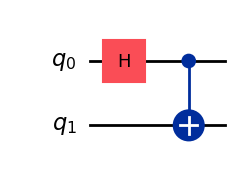

In [ ]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(2)

qc.h(0)
qc.cx(0, 1)

qc.draw(output='mpl')
# No he ejecutado el circuito, pero si lo hiciera, obtendría un estado de Bell 
# entre los dos qubits.

In [2]:
from qiskit.quantum_info import Pauli
# Paulis para medir correlaciones entre qubits, esto significa
# que se pueden medir correlaciones entre los qubits en un estado de Bell.
# Las correlaciones significan que si se mide un qubit, el otro qubit
# tendrá un valor correlacionado con el primero, incluso si están separados
# por una gran distancia. Esto es lo que se conoce como entrelazamiento cuántico.
# Los estados de Bell son un ejemplo de entrelazamiento cuántico.

# Pauli ZZ significa que se mide el primer qubit en la base Z y el segundo qubit en la base Z.
ZZ = Pauli('ZZ')
# Pauli ZI significa que se mide el primer qubit en la base Z y el segundo qubit en la base I 
# (identidad).
ZI = Pauli('ZI')
# Pauli IZ significa que se mide el primer qubit en la base I (identidad) y el segundo qubit 
# en la base Z.
IZ = Pauli('IZ')
# Pauli XX significa que se mide el primer qubit en la base X y el segundo qubit en la base X.
XX = Pauli('XX')
# Pauli IX significa que se mide el primer qubit en la base I (identidad) y el segundo qubit
# en la base X.
XI = Pauli('XI')
# Pauli XI significa que se mide el primer qubit en la base X y el segundo qubit en la base 
# I (identidad).
IX = Pauli('IX')

observables = [ZZ, ZI, IZ, XX, XI, IX]

**Step 2: Optimize**

no permite optimizar no tiene conexión

In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService
 
service = QiskitRuntimeService()
 
backend = service.least_busy(simulator=False, operational=True)
 
# Convert to an ISA circuit and layout-mapped observables.
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(qc)
 
isa_circuit.draw("mpl", idle_wires=False)

AccountNotFoundError: 'Unable to find account.'

## CIRCUITO 4

https://www.youtube.com/watch?v=93-zLTppFZw&list=PLZIvznntA6uKiXmqwd9xEWAWK0CUhtImA&index=1&t=48s

https://github.com/derek-wang-ibm/coding-with-qiskit/blob/main/episode-3-hello-world.ipynb

https://github.com/qiskit-community/qiskit-community-tutorials/blob/master/Coding_With_Qiskit/ep4_Gates.ipynb

https://www.youtube.com/watch?v=RrUTwq5jKM4
https://github.com/qiskit-community/qiskit-community-tutorials/blob/master/Coding_With_Qiskit/ep3_Hello_World.ipynb


## CIRCUITO 4

conexiones con token o apikey

In [11]:
import json
with open('/home/miguel/pruebasQiskit/apikey.json', 'r') as f:
        config = json.load(f)
token= config['token']
token

'eyJraWQiOiIyMDE5MDcyNCIsImFsZyI6IlJTMjU2In0.eyJpYW1faWQiOiJJQk1pZC02OTcwMDBTVENXI  iwiaWQiOiJJQk1pZC02OTcwMDBTVENXIiwicmVhbG1pZCI6IklCTWlkIiwianRpIjoiMTkyMGEyMzMtNTQ3Mi00ZWI2LWJjOWU  tMTRjN2M2MjY1ZGU2IiwiaWRlbnRpZmllciI6IjY5NzAwMFNUQ1ciLCJnaXZlbl9uYW1lIjoiTWlndWVsIMOBbmdlbCIsImZhb  WlseV9uYW1lIjoiUnViaW8gZGUgRGllZ28iLCJuYW1lIjoiTWlndWVsIMOBbmdlbCBSdWJpbyBkZSBEaWVnbyIsImVtYWlsIjo  iaW1hcmRpZWdvQGdtYWlsLmNvbSIsInN1YiI6ImltYXJkaWVnb0BnbWFpbC5jb20iLCJhdXRobiI6eyJzdWIiOiJpbWFyZGllZ  29AZ21haWwuY29tIiwiaWFtX2lkIjoiSUJNaWQtNjk3MDAwU1RDVyIsIm5hbWUiOiJNaWd1ZWwgw4FuZ2VsIFJ1YmlvIGRlIER  pZWdvIiwiZ2l2ZW5fbmFtZSI6Ik1pZ3VlbCDDgW5nZWwiLCJmYW1pbHlfbmFtZSI6IlJ1YmlvIGRlIERpZWdvIiwiZW1haWwiO  iJpbWFyZGllZ29AZ21haWwuY29tIn0sImFjY291bnQiOnsidmFsaWQiOnRydWUsImJzcyI6IjVhOTY2YjJhZjQyYTQ2MTE5YWV  mMTJmYTEzYTc0NDA0IiwiZnJvemVuIjp0cnVlfSwiaWF0IjoxNzU0MzMyNzk1LCJleHAiOjE3NTQzMzYzOTUsImlzcyI6Imh0d  HBzOi8vaWFtLmNsb3VkLmlibS5jb20vaWRlbnRpdHkiLCJncmFudF90eXBlIjoidXJuOmlibTpwYXJhbXM6b2F1dGg6Z3JhbnQ  tdHlwZTphcGlrZXk

In [12]:
from qiskit_ibm_runtime import QiskitRuntimeService
service = QiskitRuntimeService(channel="ibm_quantum", token=token)

IBMNotAuthorizedError: '401 Client Error: Unauthorized for url: https://auth.quantum.ibm.com/api/users/loginWithToken. Login failed., Error code: 3446.'